In [1]:
import os
import platform
import resource
import shutil
import sys
import time
from pathlib import Path

import ipykernel
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import nbconvert
import nbformat
import numpy as np
import pandas as pd
import sklearn
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter


# Task 1 — Exploratory Data Analysis

## Business question
How do spending level and composition, regional channel adoption, merchant-category usage, and age-cohort financial wellbeing vary across the synthetic 2025 consumer population? This notebook answers the five official Task 1 questions on pp. 6–7 of `docs/BI10_ROUND01.pdf`.

## Data provenance and grain

- `consumer_financial_health_engagement_2025.csv`: one observed **consumer-month** per row. It is the authoritative source for monthly financial-health scores, ratios, and Q2.
- `consumer_transactions_2025.csv`: one **transaction** per row. It is read in bounded chunks for reconciliation and transaction-detail questions.
- `data_dictionary.xlsx`: field semantics, units, and valid channel values. It is documentation only and is not loaded programmatically.

Both analytical files cover calendar 2025 and contain synthetic records. No row is interpreted as a real person or realistic absolute financial position. Observed months are retained as observed; missing consumer-months are never filled with zero.

In [2]:
run_started_at = time.perf_counter()
runtime_cwd = Path.cwd().resolve()
project_root_override = os.environ.get("BI_PROJECT_ROOT")

if project_root_override:
    PROJECT_ROOT = Path(project_root_override).expanduser().resolve()
    if not PROJECT_ROOT.is_dir():
        raise FileNotFoundError(f"BI_PROJECT_ROOT is not a directory: {PROJECT_ROOT}")
else:
    if runtime_cwd.name != "code":
        raise RuntimeError(
            "Run this notebook with cwd set to the repository's code/ directory, "
            "or set BI_PROJECT_ROOT to the repository root. "
            f"Observed cwd: {runtime_cwd}"
        )
    PROJECT_ROOT = runtime_cwd.parent

DATA_DIR = Path(os.environ.get("BI_DATA_DIR", PROJECT_ROOT / "data")).expanduser().resolve()
ARTIFACT_ROOT = Path(os.environ.get("BI_OUTPUT_DIR", PROJECT_ROOT)).expanduser().resolve()
FIGURE_DIR = ARTIFACT_ROOT / "image" / "task1"
OUTPUT_DIR = ARTIFACT_ROOT / "code" / "outputs"
MONTHLY_PATH = DATA_DIR / "consumer_financial_health_engagement_2025.csv"
TRANSACTION_PATH = DATA_DIR / "consumer_transactions_2025.csv"

missing_inputs = [str(path) for path in (MONTHLY_PATH, TRANSACTION_PATH) if not path.is_file()]
if missing_inputs:
    raise FileNotFoundError("Required input file(s) absent: " + ", ".join(missing_inputs))

def ensure_writable_directory(directory: Path) -> None:
    try:
        directory.mkdir(parents=True, exist_ok=True)
        probe_path = directory / ".bi_write_probe"
        probe_path.write_text("writable", encoding="utf-8")
        probe_path.unlink()
    except OSError as error:
        raise RuntimeError(f"Artifact directory is not writable: {directory}") from error

ensure_writable_directory(FIGURE_DIR)
ensure_writable_directory(OUTPUT_DIR)

environment_versions = pd.DataFrame(
    {
        "component": ["Python", "numpy", "pandas", "matplotlib", "seaborn", "scikit-learn", "nbformat", "nbconvert", "ipykernel"],
        "version": [platform.python_version(), np.__version__, pd.__version__, matplotlib.__version__, sns.__version__, sklearn.__version__, nbformat.__version__, nbconvert.__version__, ipykernel.__version__],
    }
)
display(environment_versions)
print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Artifact root: {ARTIFACT_ROOT}")


,component,version
0,Python,3.11.15
1,numpy,2.1.3
2,pandas,2.2.3
3,matplotlib,3.9.2
4,seaborn,0.13.2
5,scikit-learn,1.5.2
6,nbformat,5.10.4
7,nbconvert,7.16.4
8,ipykernel,6.29.5


Project root: /home/pearspringmind/Studying/BI-UEL
Data directory: /home/pearspringmind/Studying/BI-UEL/data
Artifact root: /home/pearspringmind/Studying/BI-UEL


## Consumer-month load and boundary validation

The expected schema, month key, grain, coverage, row count, and customer count are asserted before analysis. Assertions intentionally stop execution if the supplied dataset differs from the accepted case-study contract.

In [3]:
MONTHLY_COLUMNS = [
    "consumer_id", "analysis_month", "age", "province_city",
    "total_spend_vnd", "essential_spend_vnd", "discretionary_spend_vnd",
    "transaction_count", "financial_health_score",
    "essential_spend_ratio", "spend_to_income_ratio",
]
MONTHLY_DTYPES = {
    "consumer_id": "string",
    "age": "int16",
    "province_city": "string",
    "total_spend_vnd": "int64",
    "essential_spend_vnd": "int64",
    "discretionary_spend_vnd": "int64",
    "transaction_count": "int32",
    "financial_health_score": "float64",
    "essential_spend_ratio": "float64",
    "spend_to_income_ratio": "float64",
}
monthly_data = pd.read_csv(
    MONTHLY_PATH,
    usecols=MONTHLY_COLUMNS,
    dtype=MONTHLY_DTYPES,
    parse_dates=["analysis_month"],
)

if monthly_data[MONTHLY_COLUMNS].isna().any().any():
    missing_counts = monthly_data[MONTHLY_COLUMNS].isna().sum()
    raise ValueError(f"Unexpected nulls in required monthly fields:\n{missing_counts[missing_counts.gt(0)]}")
if len(monthly_data) != 10_992:
    raise AssertionError(f"Expected 10,992 consumer-month rows; found {len(monthly_data):,}.")
if monthly_data["consumer_id"].nunique() != 999:
    raise AssertionError(f"Expected 999 consumers; found {monthly_data['consumer_id'].nunique():,}.")
if monthly_data.duplicated(["consumer_id", "analysis_month"]).any():
    raise AssertionError("consumer_id + analysis_month is not unique in the monthly source.")
if not monthly_data["analysis_month"].dt.year.eq(2025).all() or not monthly_data["analysis_month"].dt.day.eq(1).all():
    raise AssertionError("analysis_month must be the first day of a calendar month in 2025.")
if not monthly_data["analysis_month"].dt.month.nunique() == 12:
    raise AssertionError("The monthly source does not cover all 12 months of 2025.")
if not (monthly_data["total_spend_vnd"] == monthly_data["essential_spend_vnd"] + monthly_data["discretionary_spend_vnd"]).all():
    raise AssertionError("Monthly total spend does not equal essential plus discretionary spend.")

monthly_quality_summary = pd.DataFrame(
    {
        "check": ["rows", "unique consumer-month keys", "unique consumers", "observed months"],
        "value": [len(monthly_data), monthly_data[["consumer_id", "analysis_month"]].drop_duplicates().shape[0], monthly_data["consumer_id"].nunique(), monthly_data["analysis_month"].nunique()],
    }
)
display(monthly_quality_summary)


,check,value
0,rows,10992
1,unique consumer-month keys,10992
2,unique consumers,999
3,observed months,12


## Bounded transaction scan and aggregation

Only nine required columns are read in 100,000-row chunks. Exact transaction-ID uniqueness is established without retaining IDs: IDs must be strictly increasing within every chunk and across chunk boundaries, which mathematically precludes duplicates. The scan retains only small additive aggregates. Timestamp month and declared `transaction_month` must agree on every row.

In [4]:
TRANSACTION_COLUMNS = [
    "transaction_id", "activity_datetime", "consumer_id", "province_city",
    "spending_category", "spend_amount_vnd", "transaction_channel",
    "online_transaction_flag", "transaction_month",
]
TRANSACTION_DTYPES = {
    "transaction_id": "string",
    "activity_datetime": "string",
    "consumer_id": "string",
    "province_city": "string",
    "spending_category": "string",
    "spend_amount_vnd": "int64",
    "transaction_channel": "string",
    "online_transaction_flag": "int8",
    "transaction_month": "int8",
}
EXPECTED_CHANNELS = {"POS", "E-commerce", "Mobile App", "QR Payment", "Recurring Payment"}
CHUNK_SIZE = 100_000
customer_month_parts = []
transaction_month_parts = []
province_parts = []
province_channel_parts = []
category_parts = []
channel_online_parts = []
transaction_row_count = 0
previous_transaction_id = None
observed_channels = set()

for chunk_number, transaction_chunk in enumerate(
    pd.read_csv(TRANSACTION_PATH, usecols=TRANSACTION_COLUMNS, dtype=TRANSACTION_DTYPES, chunksize=CHUNK_SIZE),
    start=1,
):
    if transaction_chunk[TRANSACTION_COLUMNS].isna().any().any():
        raise ValueError(f"Unexpected null in required transaction fields in chunk {chunk_number}.")
    transaction_ids = transaction_chunk["transaction_id"]
    if not transaction_ids.is_unique or not transaction_ids.is_monotonic_increasing:
        raise AssertionError(f"Transaction IDs are not strictly ordered and unique in chunk {chunk_number}.")
    if previous_transaction_id is not None and previous_transaction_id >= transaction_ids.iloc[0]:
        raise AssertionError(f"Transaction ID order/uniqueness fails at chunk boundary {chunk_number}.")
    previous_transaction_id = transaction_ids.iloc[-1]

    transaction_chunk["activity_datetime"] = pd.to_datetime(transaction_chunk["activity_datetime"], errors="raise")
    if not transaction_chunk["activity_datetime"].dt.year.eq(2025).all():
        raise AssertionError(f"Out-of-window transaction timestamp in chunk {chunk_number}.")
    if not transaction_chunk["transaction_month"].between(1, 12).all():
        raise AssertionError(f"Invalid transaction_month in chunk {chunk_number}.")
    timestamp_month = transaction_chunk["activity_datetime"].dt.to_period("M").dt.to_timestamp()
    declared_month = pd.to_datetime(
        {
            "year": np.full(len(transaction_chunk), 2025, dtype=np.int16),
            "month": transaction_chunk["transaction_month"].to_numpy(),
            "day": np.ones(len(transaction_chunk), dtype=np.int8),
        }
    )
    if not timestamp_month.reset_index(drop=True).equals(declared_month.reset_index(drop=True)):
        raise AssertionError(f"Timestamp month disagrees with transaction_month in chunk {chunk_number}.")
    if not transaction_chunk["online_transaction_flag"].isin([0, 1]).all():
        raise AssertionError(f"Invalid online_transaction_flag in chunk {chunk_number}.")

    transaction_chunk["analysis_month"] = timestamp_month
    transaction_chunk["digital_transaction_flag"] = transaction_chunk["transaction_channel"].ne("POS").astype("int8")
    observed_channels.update(transaction_chunk["transaction_channel"].unique().tolist())
    transaction_row_count += len(transaction_chunk)

    customer_month_parts.append(
        transaction_chunk.groupby(["consumer_id", "analysis_month"], as_index=False, observed=True).agg(
            transaction_count_tx=("transaction_id", "size"),
            total_spend_vnd_tx=("spend_amount_vnd", "sum"),
        )
    )
    transaction_month_parts.append(
        transaction_chunk.groupby("analysis_month", as_index=False, observed=True).agg(
            transaction_count=("transaction_id", "size"),
            total_spend_vnd=("spend_amount_vnd", "sum"),
        )
    )
    province_parts.append(
        transaction_chunk.groupby("province_city", as_index=False, observed=True).agg(
            transaction_count=("transaction_id", "size"),
            total_spend_vnd=("spend_amount_vnd", "sum"),
            digital_transaction_count=("digital_transaction_flag", "sum"),
            online_transaction_count=("online_transaction_flag", "sum"),
        )
    )
    province_channel_parts.append(
        transaction_chunk.groupby(["province_city", "transaction_channel"], as_index=False, observed=True).agg(
            transaction_count=("transaction_id", "size")
        )
    )
    category_parts.append(
        transaction_chunk.groupby("spending_category", as_index=False, observed=True).agg(
            transaction_count=("transaction_id", "size"),
            total_spend_vnd=("spend_amount_vnd", "sum"),
        )
    )
    channel_online_parts.append(
        transaction_chunk.groupby("transaction_channel", as_index=False, observed=True).agg(
            transaction_count=("transaction_id", "size"),
            online_transaction_count=("online_transaction_flag", "sum"),
        )
    )

if transaction_row_count != 1_852_394:
    raise AssertionError(f"Expected 1,852,394 transaction rows; found {transaction_row_count:,}.")
if observed_channels != EXPECTED_CHANNELS:
    raise AssertionError(f"Expected channels {sorted(EXPECTED_CHANNELS)}; found {sorted(observed_channels)}.")

def combine_additive_parts(parts: list[pd.DataFrame], keys: list[str]) -> pd.DataFrame:
    return pd.concat(parts, ignore_index=True).groupby(keys, as_index=False, observed=True).sum(numeric_only=True)

transaction_customer_month = combine_additive_parts(customer_month_parts, ["consumer_id", "analysis_month"])
transaction_month_summary = combine_additive_parts(transaction_month_parts, ["analysis_month"])
province_summary = combine_additive_parts(province_parts, ["province_city"])
province_channel_summary = combine_additive_parts(province_channel_parts, ["province_city", "transaction_channel"])
category_summary = combine_additive_parts(category_parts, ["spending_category"])
channel_online_summary = combine_additive_parts(channel_online_parts, ["transaction_channel"])

del customer_month_parts, transaction_month_parts, province_parts, province_channel_parts, category_parts, channel_online_parts
print(f"Streamed and aggregated {transaction_row_count:,} transaction rows in chunks of at most {CHUNK_SIZE:,}.")


Streamed and aggregated 1,852,394 transaction rows in chunks of at most 100,000.


In [5]:
monthly_reconciliation = monthly_data[["consumer_id", "analysis_month", "transaction_count", "total_spend_vnd"]].merge(
    transaction_customer_month,
    on=["consumer_id", "analysis_month"],
    how="outer",
    validate="one_to_one",
    indicator=True,
)
if not monthly_reconciliation["_merge"].eq("both").all():
    mismatch_counts = monthly_reconciliation["_merge"].value_counts().to_dict()
    raise AssertionError(f"Consumer-month keys do not reconcile: {mismatch_counts}")
if not monthly_reconciliation["transaction_count"].eq(monthly_reconciliation["transaction_count_tx"]).all():
    raise AssertionError("Transaction counts do not reconcile exactly by consumer-month.")
if not monthly_reconciliation["total_spend_vnd"].eq(monthly_reconciliation["total_spend_vnd_tx"]).all():
    raise AssertionError("Spend does not reconcile exactly by consumer-month.")
if int(transaction_customer_month["transaction_count_tx"].sum()) != transaction_row_count:
    raise AssertionError("Aggregated transaction count does not match streamed row count.")
if int(transaction_customer_month["total_spend_vnd_tx"].sum()) != int(monthly_data["total_spend_vnd"].sum()):
    raise AssertionError("Annual transaction spend does not match the monthly source.")

reconciliation_summary = pd.DataFrame(
    {
        "check": ["transaction rows / unique ordered IDs", "reconciled consumer-month keys", "transaction-count differences", "spend differences (VND)"],
        "value": [transaction_row_count, len(monthly_reconciliation), int((monthly_reconciliation["transaction_count"] - monthly_reconciliation["transaction_count_tx"]).abs().sum()), int((monthly_reconciliation["total_spend_vnd"] - monthly_reconciliation["total_spend_vnd_tx"]).abs().sum())],
    }
)
display(reconciliation_summary)


,check,value
0,transaction rows / unique ordered IDs,1852394
1,reconciled consumer-month keys,10992
2,transaction-count differences,0
3,spend differences (VND),0


## Fixed metric sheet

This sheet fixes the numerator, denominator, date window, analytical grain, customer scope, and weighting before results are selected. **Digital** means every non-POS channel, including QR Payment. **Online** means `online_transaction_flag == 1`; QR is therefore digital but not automatically online. Monetary-weighted shares are ratios of pooled VND sums; customer-weighted means give each distinct customer equal weight after aggregating that customer's observed months.

In [6]:
metric_sheet = pd.DataFrame(
    [
        ["Monthly/annual spend share", "Spend VND in month", "Spend VND in all observed 2025 transactions", "2025-01-01 to 2025-12-31", "transaction aggregated to month", "999 observed customers", "Transaction/VND weighted"],
        ["Average ticket", "Spend VND", "Transaction count", "2025-01-01 to 2025-12-31", "month or category", "999 observed customers", "Transaction weighted"],
        ["Essential monetary share", "Essential spend VND", "Essential + discretionary spend VND", "Observed consumer-months in 2025", "financial-health group", "Group-specific distinct customers reported", "Pooled-VND weighted"],
        ["Essential customer share", "Each customer's essential spend VND", "That customer's essential + discretionary spend VND", "Observed group-months in 2025", "customer within health group", "Group-specific distinct customers reported", "Equal weight per customer"],
        ["Digital transaction share", "Non-POS transactions, including QR", "All transactions", "2025-01-01 to 2025-12-31", "province", "Customers observed in each province", "Transaction-count weighted; not online flag"],
        ["Online transaction share", "Transactions where online_transaction_flag = 1", "All transactions", "2025-01-01 to 2025-12-31", "province/channel", "Customers observed in each province", "Transaction-count weighted; distinct from digital"],
        ["Category leaders", "Transaction count or spend VND", "All transactions", "2025-01-01 to 2025-12-31", "spending category", "999 observed customers", "Transaction/VND weighted"],
        ["Age-cohort health and ratios", "Sum of monthly metric values", "Observed consumer-months (primary) or customers (sensitivity)", "Observed consumer-months in 2025", "predefined age cohort", "Cohort row/customer counts reported", "Primary month-weighted; sensitivity customer-weighted"],
    ],
    columns=["metric", "numerator", "denominator", "date_window", "row_grain", "customers", "weighting_or_distinction"],
)
display(metric_sheet)


,metric,numerator,denominator,date_window,row_grain,customers,weighting_or_distinction
0,Monthly/annual spend share,Spend VND in month,Spend VND in all observed 2025 transactions,2025-01-01 to 2025-12-31,transaction aggregated to month,999 observed customers,Transaction/VND weighted
1,Average ticket,Spend VND,Transaction count,2025-01-01 to 2025-12-31,month or category,999 observed customers,Transaction weighted
2,Essential monetary share,Essential spend VND,Essential + discretionary spend VND,Observed consumer-months in 2025,financial-health group,Group-specific distinct customers reported,Pooled-VND weighted
3,Essential customer share,Each customer's essential spend VND,That customer's essential + discretionary spen...,Observed group-months in 2025,customer within health group,Group-specific distinct customers reported,Equal weight per customer
4,Digital transaction share,"Non-POS transactions, including QR",All transactions,2025-01-01 to 2025-12-31,province,Customers observed in each province,Transaction-count weighted; not online flag
5,Online transaction share,Transactions where online_transaction_flag = 1,All transactions,2025-01-01 to 2025-12-31,province/channel,Customers observed in each province,Transaction-count weighted; distinct from digital
6,Category leaders,Transaction count or spend VND,All transactions,2025-01-01 to 2025-12-31,spending category,999 observed customers,Transaction/VND weighted
7,Age-cohort health and ratios,Sum of monthly metric values,Observed consumer-months (primary) or customer...,Observed consumer-months in 2025,predefined age cohort,Cohort row/customer counts reported,Primary month-weighted; sensitivity customer-w...


## Q1 — Peak and trough monthly spend

**Question.** Which month has the highest spend, what annual share does it represent relative to the lowest month, and is the gap driven primarily by transaction count or ticket size?

**Method.** Monthly spend and count come from the reconciled transaction scan. Average ticket is spend/count. The peak–trough spend gap is decomposed symmetrically: count effect = change in count × mean of the two ticket sizes; ticket effect = change in ticket × mean of the two counts. The two effects sum to the observed gap.

In [7]:
q1_monthly = transaction_month_summary.sort_values("analysis_month").copy()
q1_monthly["average_ticket_vnd"] = q1_monthly["total_spend_vnd"] / q1_monthly["transaction_count"]
annual_spend_vnd = int(q1_monthly["total_spend_vnd"].sum())
q1_monthly["annual_spend_share"] = q1_monthly["total_spend_vnd"] / annual_spend_vnd
peak_month = q1_monthly.loc[q1_monthly["total_spend_vnd"].idxmax()]
trough_month = q1_monthly.loc[q1_monthly["total_spend_vnd"].idxmin()]
spend_gap_vnd = float(peak_month["total_spend_vnd"] - trough_month["total_spend_vnd"])
count_effect_vnd = float((peak_month["transaction_count"] - trough_month["transaction_count"]) * (peak_month["average_ticket_vnd"] + trough_month["average_ticket_vnd"]) / 2)
ticket_effect_vnd = float((peak_month["average_ticket_vnd"] - trough_month["average_ticket_vnd"]) * (peak_month["transaction_count"] + trough_month["transaction_count"]) / 2)
if not np.isclose(count_effect_vnd + ticket_effect_vnd, spend_gap_vnd, atol=1.0):
    raise AssertionError("Q1 decomposition does not reconcile to the spend gap.")
q1_primary_driver = "transaction count" if abs(count_effect_vnd) >= abs(ticket_effect_vnd) else "average ticket size"

q1_peak_trough = pd.DataFrame([peak_month, trough_month], index=["Peak", "Trough"])[["analysis_month", "total_spend_vnd", "annual_spend_share", "transaction_count", "average_ticket_vnd"]]
q1_decomposition = pd.DataFrame(
    {"driver": ["Transaction-count effect", "Average-ticket effect", "Observed peak–trough gap"], "effect_vnd": [count_effect_vnd, ticket_effect_vnd, spend_gap_vnd]}
)
display(q1_peak_trough.round({"annual_spend_share": 4, "average_ticket_vnd": 0}))
display(q1_decomposition.round({"effect_vnd": 0}))


,analysis_month,total_spend_vnd,annual_spend_share,transaction_count,average_ticket_vnd
Peak,2025-12-01,488032709000,0.1504,280598,1739259.0
Trough,2025-02-01,174365111000,0.0537,97657,1785485.0


,driver,effect_vnd
0,Transaction-count effect,3.224101e+11
1,Average-ticket effect,-8.742537e+09
2,Observed peak–trough gap,3.136676e+11


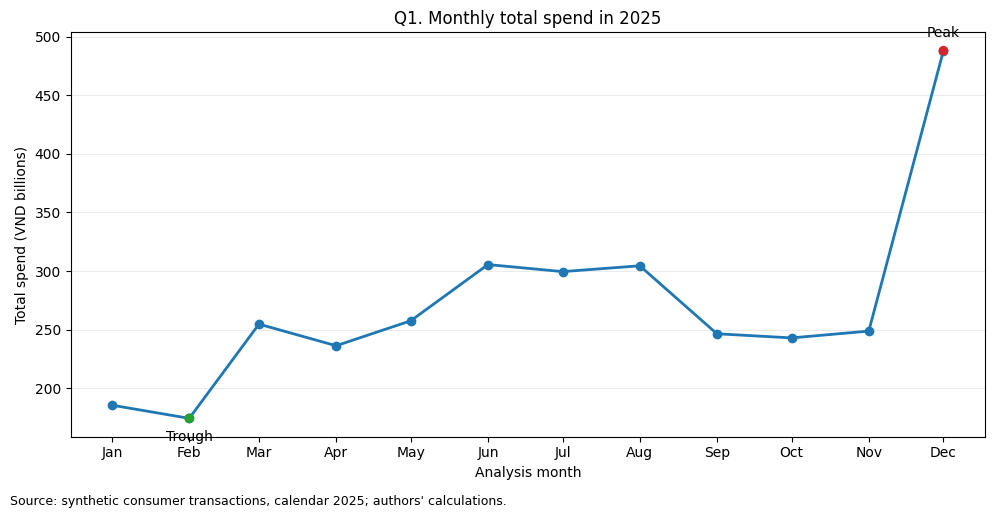

**Calculated interpretation.** December is the peak at **488,032,709,000 VND** (**15.04%** of annual spend), versus February at **174,365,111,000 VND** (**5.37%**). The **313,667,598,000 VND** gap is driven more by **transaction count**: count effect **322,410,134,807 VND** versus ticket effect **-8,742,536,807 VND**. This is a descriptive calendar pattern; the dataset alone does not support attributing it to a holiday, promotion, or other seasonal cause.

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(q1_monthly["analysis_month"], q1_monthly["total_spend_vnd"] / 1e9, marker="o", linewidth=2, color="#1f77b4")
ax.scatter([peak_month["analysis_month"], trough_month["analysis_month"]], [peak_month["total_spend_vnd"] / 1e9, trough_month["total_spend_vnd"] / 1e9], color=["#d62728", "#2ca02c"], zorder=3)
ax.annotate("Peak", (peak_month["analysis_month"], peak_month["total_spend_vnd"] / 1e9), xytext=(0, 10), textcoords="offset points", ha="center")
ax.annotate("Trough", (trough_month["analysis_month"], trough_month["total_spend_vnd"] / 1e9), xytext=(0, -16), textcoords="offset points", ha="center")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set(title="Q1. Monthly total spend in 2025", xlabel="Analysis month", ylabel="Total spend (VND billions)")
ax.grid(axis="y", alpha=0.25)
fig.text(0.01, -0.02, "Source: synthetic consumer transactions, calendar 2025; authors' calculations.", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "q1_monthly_spend.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
display(Markdown(
    f"**Calculated interpretation.** {peak_month['analysis_month']:%B} is the peak at **{peak_month['total_spend_vnd']:,.0f} VND** "
    f"(**{peak_month['annual_spend_share']:.2%}** of annual spend), versus {trough_month['analysis_month']:%B} at "
    f"**{trough_month['total_spend_vnd']:,.0f} VND** (**{trough_month['annual_spend_share']:.2%}**). The **{spend_gap_vnd:,.0f} VND** gap is driven more by "
    f"**{q1_primary_driver}**: count effect **{count_effect_vnd:,.0f} VND** versus ticket effect **{ticket_effect_vnd:,.0f} VND**. "
    "This is a descriptive calendar pattern; the dataset alone does not support attributing it to a holiday, promotion, or other seasonal cause."
))


**Interpretation and source.** The calculated statement rendered immediately below Figure Q1 supplies the peak/trough values, annual-share comparator, and reconciled count-versus-ticket decomposition. It describes temporal concentration only; no external seasonal mechanism is claimed. Source: synthetic transaction-level data, calendar 2025.

## Q2 — Essential versus discretionary allocation by financial health

**Question.** How does spending composition differ between stressed consumer-months (`financial_health_score < 40`) and healthy consumer-months (`financial_health_score >= 80`)?

**Method.** This question uses the monthly table directly—no transaction join. The pooled-VND result answers the budget-allocation question; an equal-customer sensitivity first pools each customer's observed months within a group and then averages customer shares. A customer may appear in both groups if their score changes over time, so both consumer-month and distinct-customer counts are reported.

In [9]:
q2_rows = monthly_data.loc[monthly_data["financial_health_score"].lt(40) | monthly_data["financial_health_score"].ge(80)].copy()
q2_rows["health_group"] = np.where(q2_rows["financial_health_score"].lt(40), "Stressed (<40)", "Healthy (>=80)")
q2_group_totals = q2_rows.groupby("health_group", as_index=False, observed=True).agg(
    consumer_months=("consumer_id", "size"),
    distinct_customers=("consumer_id", "nunique"),
    essential_spend_vnd=("essential_spend_vnd", "sum"),
    discretionary_spend_vnd=("discretionary_spend_vnd", "sum"),
)
q2_group_totals["monetary_essential_share"] = q2_group_totals["essential_spend_vnd"] / (q2_group_totals["essential_spend_vnd"] + q2_group_totals["discretionary_spend_vnd"])
q2_group_totals["monetary_discretionary_share"] = 1 - q2_group_totals["monetary_essential_share"]
q2_customer_totals = q2_rows.groupby(["health_group", "consumer_id"], as_index=False, observed=True).agg(
    essential_spend_vnd=("essential_spend_vnd", "sum"),
    discretionary_spend_vnd=("discretionary_spend_vnd", "sum"),
)
q2_customer_totals["customer_essential_share"] = q2_customer_totals["essential_spend_vnd"] / (q2_customer_totals["essential_spend_vnd"] + q2_customer_totals["discretionary_spend_vnd"])
q2_customer_weighted = q2_customer_totals.groupby("health_group", as_index=False, observed=True).agg(average_customer_essential_share=("customer_essential_share", "mean"))
q2_summary = q2_group_totals.merge(q2_customer_weighted, on="health_group", validate="one_to_one")
q2_summary["average_customer_discretionary_share"] = 1 - q2_summary["average_customer_essential_share"]
if set(q2_summary["health_group"]) != {"Stressed (<40)", "Healthy (>=80)"}:
    raise AssertionError("Q2 requires non-empty stressed and healthy groups.")
q2_indexed = q2_summary.set_index("health_group")
q2_essential_gap_pp = float((q2_indexed.loc["Stressed (<40)", "monetary_essential_share"] - q2_indexed.loc["Healthy (>=80)", "monetary_essential_share"]) * 100)
display(q2_summary.round({"monetary_essential_share": 4, "monetary_discretionary_share": 4, "average_customer_essential_share": 4, "average_customer_discretionary_share": 4}))
print(f"Stressed minus healthy monetary essential-share gap: {q2_essential_gap_pp:+.2f} percentage points")


,health_group,consumer_months,distinct_customers,essential_spend_vnd,discretionary_spend_vnd,monetary_essential_share,monetary_discretionary_share,average_customer_essential_share,average_customer_discretionary_share
0,Healthy (>=80),475,303,33173771000,22617859000,0.5946,0.4054,0.6116,0.3884
1,Stressed (<40),95,70,9579242000,24198127000,0.2836,0.7164,0.2782,0.7218


Stressed minus healthy monetary essential-share gap: -31.10 percentage points


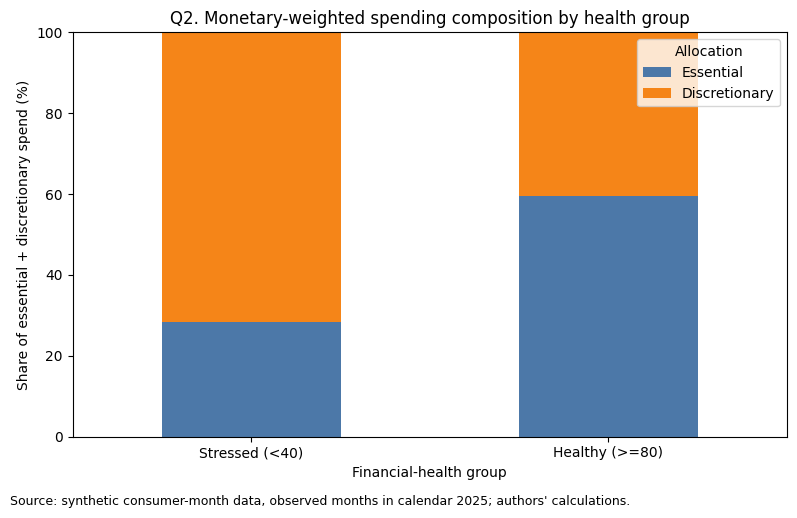

**Calculated interpretation.** Stressed observations allocate **28.36%** to essentials versus **59.46%** for healthy observations, a **-31.10 percentage-point** gap (lower for stressed observations). The comparison covers **95** stressed consumer-months / **70** customers and **475** healthy consumer-months / **303** customers. Equal-customer essential shares are **27.82%** and **61.16%**, respectively. These are associations within observed synthetic months, not evidence that financial stress causes a particular allocation.

In [10]:
q2_plot = q2_summary.set_index("health_group").loc[["Stressed (<40)", "Healthy (>=80)"], ["monetary_essential_share", "monetary_discretionary_share"]] * 100
fig, ax = plt.subplots(figsize=(8, 5))
q2_plot.plot(kind="bar", stacked=True, color=["#4c78a8", "#f58518"], ax=ax)
ax.set(title="Q2. Monetary-weighted spending composition by health group", xlabel="Financial-health group", ylabel="Share of essential + discretionary spend (%)", ylim=(0, 100))
ax.legend(["Essential", "Discretionary"], title="Allocation", loc="upper right")
ax.tick_params(axis="x", rotation=0)
fig.text(0.01, -0.02, "Source: synthetic consumer-month data, observed months in calendar 2025; authors' calculations.", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "q2_spend_composition.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
q2_direction = "higher" if q2_essential_gap_pp > 0 else "lower" if q2_essential_gap_pp < 0 else "the same"
display(Markdown(
    f"**Calculated interpretation.** Stressed observations allocate **{q2_indexed.loc['Stressed (<40)', 'monetary_essential_share']:.2%}** to essentials versus "
    f"**{q2_indexed.loc['Healthy (>=80)', 'monetary_essential_share']:.2%}** for healthy observations, a **{q2_essential_gap_pp:+.2f} percentage-point** gap ({q2_direction} for stressed observations). "
    f"The comparison covers **{int(q2_indexed.loc['Stressed (<40)', 'consumer_months']):,}** stressed consumer-months / **{int(q2_indexed.loc['Stressed (<40)', 'distinct_customers']):,}** customers and "
    f"**{int(q2_indexed.loc['Healthy (>=80)', 'consumer_months']):,}** healthy consumer-months / **{int(q2_indexed.loc['Healthy (>=80)', 'distinct_customers']):,}** customers. "
    f"Equal-customer essential shares are **{q2_indexed.loc['Stressed (<40)', 'average_customer_essential_share']:.2%}** and **{q2_indexed.loc['Healthy (>=80)', 'average_customer_essential_share']:.2%}**, respectively. "
    "These are associations within observed synthetic months, not evidence that financial stress causes a particular allocation."
))


**Interpretation and source.** The calculated statement below Figure Q2 reports both pooled-VND and equal-customer shares, their percentage-point comparator, and group sizes. The score groups are monthly states, not fixed customer labels, and the descriptive comparison is non-causal. Source: synthetic consumer-month data, observed months in calendar 2025.

## Q3 — Regional digital-adoption gaps among high-volume provinces

**Question.** Which two or more high-spend provinces have a below-average digital transaction share, and what does their POS-versus-digital channel mix show?

**Predefined selection.** A province is **high volume** when its 2025 total spend is at or above the median across all provinces. Among high-volume provinces with digital share below the overall transaction-count-weighted digital share, the two highest-spend provinces are selected. Digital is every non-POS channel, including QR. Online is reported separately from `online_transaction_flag`.

In [11]:
province_summary["digital_transaction_share"] = province_summary["digital_transaction_count"] / province_summary["transaction_count"]
province_summary["online_transaction_share"] = province_summary["online_transaction_count"] / province_summary["transaction_count"]
province_summary["pos_transaction_count"] = province_summary["transaction_count"] - province_summary["digital_transaction_count"]
overall_digital_share = float(province_summary["digital_transaction_count"].sum() / province_summary["transaction_count"].sum())
high_volume_spend_threshold = float(province_summary["total_spend_vnd"].median())
q3_candidates = province_summary.loc[
    province_summary["total_spend_vnd"].ge(high_volume_spend_threshold)
    & province_summary["digital_transaction_share"].lt(overall_digital_share)
].copy()
if len(q3_candidates) < 2:
    raise AssertionError("The predefined high-volume/below-average rule produced fewer than two provinces.")
q3_selected = q3_candidates.nlargest(2, "total_spend_vnd").copy()
q3_selected["digital_gap_vs_overall_pp"] = (overall_digital_share - q3_selected["digital_transaction_share"]) * 100
q3_selected["pos_transaction_share"] = q3_selected["pos_transaction_count"] / q3_selected["transaction_count"]
selected_provinces = q3_selected["province_city"].tolist()
channel_order = ["POS", "QR Payment", "E-commerce", "Mobile App", "Recurring Payment"]
q3_channel_counts = province_channel_summary.loc[province_channel_summary["province_city"].isin(selected_provinces)].pivot(index="province_city", columns="transaction_channel", values="transaction_count").fillna(0).reindex(index=selected_provinces, columns=channel_order, fill_value=0)
q3_channel_shares = q3_channel_counts.div(q3_channel_counts.sum(axis=1), axis=0)
display(q3_selected[["province_city", "total_spend_vnd", "transaction_count", "pos_transaction_count", "digital_transaction_count", "pos_transaction_share", "digital_transaction_share", "online_transaction_share", "digital_gap_vs_overall_pp"]].round(4))
display(channel_online_summary.assign(online_share=lambda table: table["online_transaction_count"] / table["transaction_count"]).round(4))
print(f"High-volume threshold (median province spend): {high_volume_spend_threshold:,.0f} VND")
print(f"Overall transaction-count-weighted digital share: {overall_digital_share:.2%}")


,province_city,total_spend_vnd,transaction_count,pos_transaction_count,digital_transaction_count,pos_transaction_share,digital_transaction_share,online_transaction_share,digital_gap_vs_overall_pp
7,Hà Nội,267264508000,149952,88658,61294,0.5912,0.4088,0.2100,0.3075
32,Đồng Nai,183072471000,106057,62865,43192,0.5927,0.4073,0.2088,0.4580


,transaction_channel,transaction_count,online_transaction_count,online_share
0,E-commerce,161670,161670,1.0
1,Mobile App,142399,142399,1.0
2,POS,1089518,0,0.0
3,QR Payment,367682,0,0.0
4,Recurring Payment,91125,91125,1.0


High-volume threshold (median province spend): 82,693,483,500 VND
Overall transaction-count-weighted digital share: 41.18%


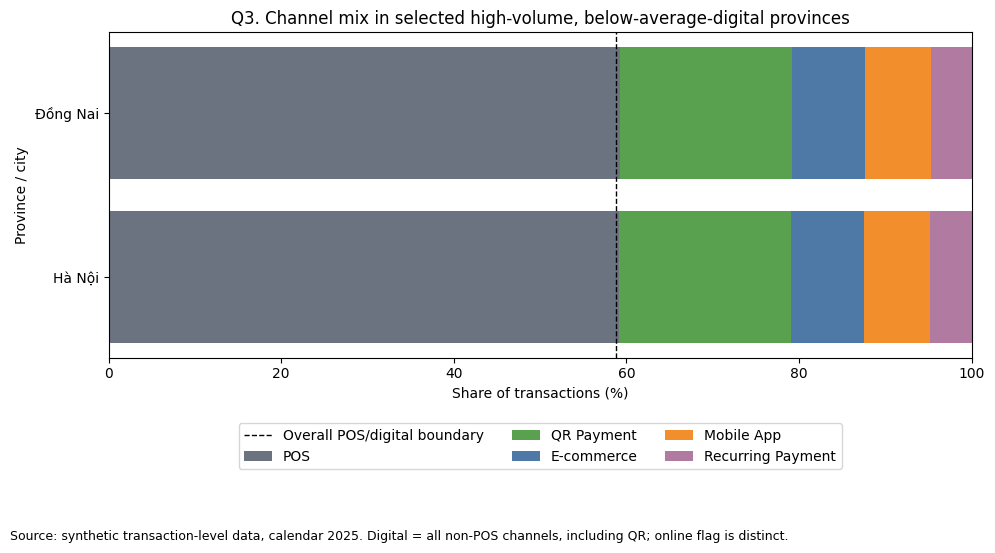

**Calculated interpretation.** With high volume fixed at **>= 82,693,483,500 VND** and overall digital share at **41.18%**, the selected gaps are: **Hà Nội: 267,264,508,000 VND spend, 40.88% digital (0.31 pp below overall), 21.00% online; Đồng Nai: 183,072,471,000 VND spend, 40.73% digital (0.46 pp below overall), 20.88% online**. The stacked bars localize the gap to channel mix rather than spend value. Digital and online percentages must not be interchanged because QR is classified as non-POS digital while the source online flag excludes it.

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
left_positions = np.zeros(len(q3_channel_shares))
channel_colors = {"POS": "#6b7280", "QR Payment": "#59a14f", "E-commerce": "#4e79a7", "Mobile App": "#f28e2b", "Recurring Payment": "#b07aa1"}
for channel in channel_order:
    channel_values = q3_channel_shares[channel].to_numpy() * 100
    ax.barh(q3_channel_shares.index, channel_values, left=left_positions, label=channel, color=channel_colors[channel])
    left_positions += channel_values
ax.axvline((1 - overall_digital_share) * 100, color="black", linestyle="--", linewidth=1, label="Overall POS/digital boundary")
ax.set(title="Q3. Channel mix in selected high-volume, below-average-digital provinces", xlabel="Share of transactions (%)", ylabel="Province / city", xlim=(0, 100))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
fig.text(0.01, -0.09, "Source: synthetic transaction-level data, calendar 2025. Digital = all non-POS channels, including QR; online flag is distinct.", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "q3_regional_channel_gap.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
q3_findings = "; ".join(
    f"{row.province_city}: {row.total_spend_vnd:,.0f} VND spend, {row.digital_transaction_share:.2%} digital ({row.digital_gap_vs_overall_pp:.2f} pp below overall), {row.online_transaction_share:.2%} online"
    for row in q3_selected.itertuples(index=False)
)
display(Markdown(
    f"**Calculated interpretation.** With high volume fixed at **>= {high_volume_spend_threshold:,.0f} VND** and overall digital share at **{overall_digital_share:.2%}**, the selected gaps are: **{q3_findings}**. "
    "The stacked bars localize the gap to channel mix rather than spend value. Digital and online percentages must not be interchanged because QR is classified as non-POS digital while the source online flag excludes it."
))


**Interpretation and source.** The calculated statement below Figure Q3 gives the precommitted high-volume cutoff, overall count-weighted benchmark, each selected province's spend, POS/digital comparison, online share, and percentage-point adoption gap. It describes synthetic transaction behavior, not infrastructure quality or customer intent. Source: synthetic transaction-level data, calendar 2025.

## Q4 — Category leaders by frequency and spend

**Question.** Which category leads transaction count, which leads total spend, and how do their VND-per-transaction ticket sizes differ?

**Method.** Count, spend, and average ticket are aggregated directly from the bounded transaction scan. Count measures usage frequency; spend combines frequency and ticket size.

In [13]:
category_summary["average_ticket_vnd"] = category_summary["total_spend_vnd"] / category_summary["transaction_count"]
count_leader = category_summary.loc[category_summary["transaction_count"].idxmax()]
spend_leader = category_summary.loc[category_summary["total_spend_vnd"].idxmax()]
q4_leaders = pd.DataFrame(
    [
        {"leader_basis": "Transaction count", **count_leader.to_dict()},
        {"leader_basis": "Total spend", **spend_leader.to_dict()},
    ]
)
q4_ticket_gap_vnd = float(spend_leader["average_ticket_vnd"] - count_leader["average_ticket_vnd"])
display(q4_leaders[["leader_basis", "spending_category", "transaction_count", "total_spend_vnd", "average_ticket_vnd"]].round({"average_ticket_vnd": 0}))
print(f"Spend-leader minus count-leader average-ticket gap: {q4_ticket_gap_vnd:,.0f} VND")


,leader_basis,spending_category,transaction_count,total_spend_vnd,average_ticket_vnd
0,Transaction count,Xăng dầu và di chuyển,188029,298389366000,1586933.0
1,Total spend,Siêu thị và tạp hóa tại cửa hàng,176191,513773547000,2916003.0


Spend-leader minus count-leader average-ticket gap: 1,329,071 VND


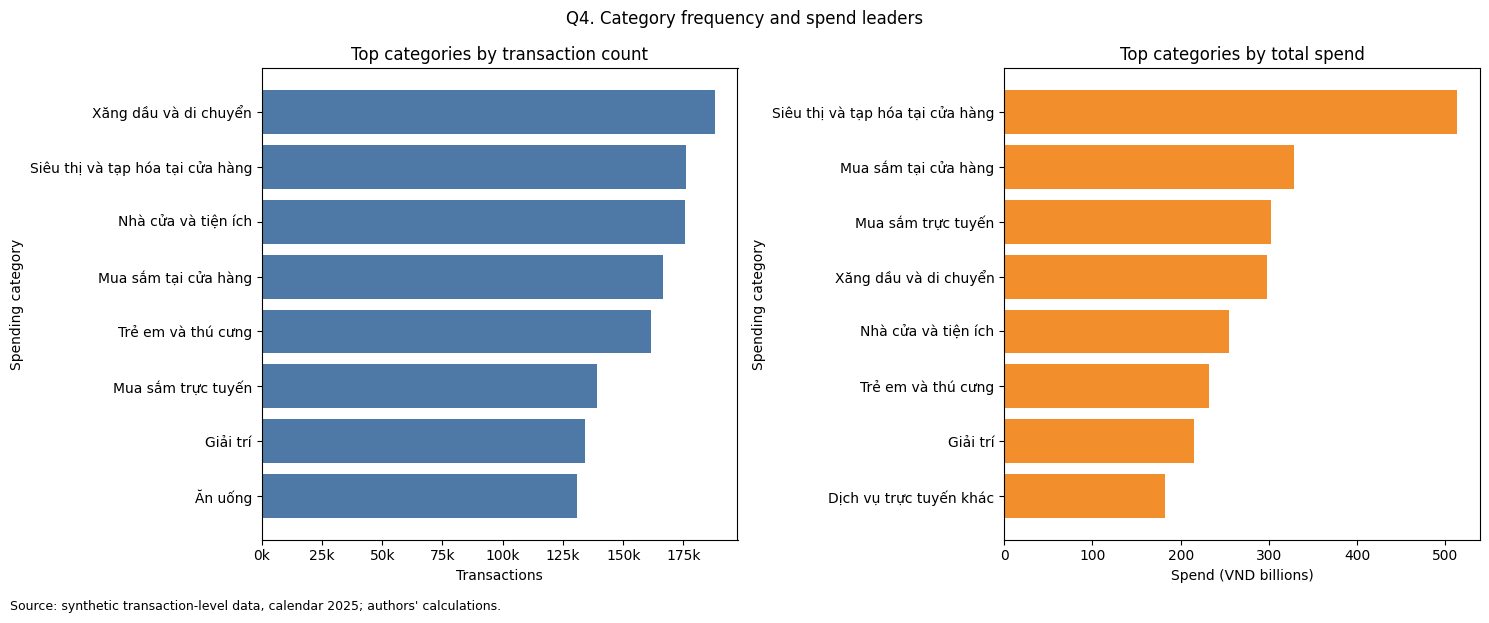

**Calculated interpretation.** **Xăng dầu và di chuyển** leads frequency with **188,029** transactions, **298,389,366,000 VND** spend, and a **1,586,933 VND** average ticket. **Siêu thị và tạp hóa tại cửa hàng** leads spend at **513,773,547,000 VND**, from **176,191** transactions with a **2,916,003 VND** average ticket. The count leader reflects more frequent use, while the spend leader's average ticket is 1,329,071 VND higher per transaction.

In [14]:
top_count_categories = category_summary.nlargest(8, "transaction_count").sort_values("transaction_count")
top_spend_categories = category_summary.nlargest(8, "total_spend_vnd").sort_values("total_spend_vnd")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(top_count_categories["spending_category"], top_count_categories["transaction_count"], color="#4e79a7")
axes[0].set(title="Top categories by transaction count", xlabel="Transactions", ylabel="Spending category")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{value / 1e3:.0f}k"))
axes[1].barh(top_spend_categories["spending_category"], top_spend_categories["total_spend_vnd"] / 1e9, color="#f28e2b")
axes[1].set(title="Top categories by total spend", xlabel="Spend (VND billions)", ylabel="Spending category")
fig.suptitle("Q4. Category frequency and spend leaders")
fig.text(0.01, -0.02, "Source: synthetic transaction-level data, calendar 2025; authors' calculations.", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "q4_category_leaders.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
if count_leader["spending_category"] == spend_leader["spending_category"]:
    q4_behavior_text = "The same category leads both measures, so its high spend reflects the combined effect of frequent use and its observed ticket size."
else:
    q4_behavior_text = (
        f"The count leader reflects more frequent use, while the spend leader's average ticket is {abs(q4_ticket_gap_vnd):,.0f} VND "
        f"{'higher' if q4_ticket_gap_vnd > 0 else 'lower'} per transaction."
    )
display(Markdown(
    f"**Calculated interpretation.** **{count_leader['spending_category']}** leads frequency with **{int(count_leader['transaction_count']):,}** transactions, "
    f"**{count_leader['total_spend_vnd']:,.0f} VND** spend, and a **{count_leader['average_ticket_vnd']:,.0f} VND** average ticket. "
    f"**{spend_leader['spending_category']}** leads spend at **{spend_leader['total_spend_vnd']:,.0f} VND**, from **{int(spend_leader['transaction_count']):,}** transactions with a **{spend_leader['average_ticket_vnd']:,.0f} VND** average ticket. "
    + q4_behavior_text
))


**Interpretation and source.** The calculated statement below Figure Q4 compares both leaders on count, total VND, and VND per ticket. Frequency and spend are distinct usage lenses; neither alone establishes need, preference, or profitability. Source: synthetic transaction-level data, calendar 2025.

## Q5 — Active age cohorts with lower financial health

**Question.** Which age cohort maintains active transaction frequency while recording the lowest average financial-health score, and how do its essential-spend and spend-to-income ratios compare?

**Predefined cohorts and activity rule.** Ages are grouped as `<25`, `25–34`, `35–44`, `45–54`, `55–64`, and `65+`. In the primary month-weighted view, an active cohort has mean monthly transaction count at or above the overall consumer-month mean. The lowest-health cohort is selected only among active cohorts. A sensitivity rerun gives every customer equal weight by averaging each customer's observed months and assigning cohort from median observed age.

In [15]:
age_bin_edges = [0, 25, 35, 45, 55, 65, np.inf]
age_bin_labels = ["<25", "25–34", "35–44", "45–54", "55–64", "65+"]
q5_monthly_rows = monthly_data.copy()
q5_monthly_rows["age_cohort"] = pd.cut(q5_monthly_rows["age"], bins=age_bin_edges, labels=age_bin_labels, right=False, ordered=True)
if q5_monthly_rows["age_cohort"].isna().any():
    raise AssertionError("At least one age falls outside the predefined Q5 bins.")
overall_monthly_frequency = float(q5_monthly_rows["transaction_count"].mean())
q5_month_weighted = q5_monthly_rows.groupby("age_cohort", as_index=False, observed=False).agg(
    consumer_months=("consumer_id", "size"),
    distinct_customers=("consumer_id", "nunique"),
    average_monthly_transactions=("transaction_count", "mean"),
    average_financial_health_score=("financial_health_score", "mean"),
    average_essential_spend_ratio=("essential_spend_ratio", "mean"),
    average_spend_to_income_ratio=("spend_to_income_ratio", "mean"),
)
q5_month_weighted["active_frequency"] = q5_month_weighted["average_monthly_transactions"].ge(overall_monthly_frequency)
q5_active_month_cohorts = q5_month_weighted.loc[q5_month_weighted["active_frequency"]]
if q5_active_month_cohorts.empty:
    raise AssertionError("No Q5 cohort meets the predefined active-frequency rule.")
q5_lowest_month_cohort = str(q5_active_month_cohorts.loc[q5_active_month_cohorts["average_financial_health_score"].idxmin(), "age_cohort"])

q5_customer_level = q5_monthly_rows.groupby("consumer_id", as_index=False, observed=True).agg(
    median_age=("age", "median"),
    average_monthly_transactions=("transaction_count", "mean"),
    average_financial_health_score=("financial_health_score", "mean"),
    average_essential_spend_ratio=("essential_spend_ratio", "mean"),
    average_spend_to_income_ratio=("spend_to_income_ratio", "mean"),
)
q5_customer_level["age_cohort"] = pd.cut(q5_customer_level["median_age"], bins=age_bin_edges, labels=age_bin_labels, right=False, ordered=True)
overall_customer_frequency = float(q5_customer_level["average_monthly_transactions"].mean())
q5_customer_weighted = q5_customer_level.groupby("age_cohort", as_index=False, observed=False).agg(
    customers=("consumer_id", "nunique"),
    average_monthly_transactions=("average_monthly_transactions", "mean"),
    average_financial_health_score=("average_financial_health_score", "mean"),
    average_essential_spend_ratio=("average_essential_spend_ratio", "mean"),
    average_spend_to_income_ratio=("average_spend_to_income_ratio", "mean"),
)
q5_customer_weighted["active_frequency"] = q5_customer_weighted["average_monthly_transactions"].ge(overall_customer_frequency)
q5_active_customer_cohorts = q5_customer_weighted.loc[q5_customer_weighted["active_frequency"]]
q5_lowest_customer_cohort = str(q5_active_customer_cohorts.loc[q5_active_customer_cohorts["average_financial_health_score"].idxmin(), "age_cohort"])
q5_sensitivity_changed = q5_lowest_month_cohort != q5_lowest_customer_cohort
display(q5_month_weighted.round(3))
display(q5_customer_weighted.round(3))
print(f"Primary active-frequency threshold: {overall_monthly_frequency:.2f} transactions per observed consumer-month")
print(f"Equal-customer active-frequency threshold: {overall_customer_frequency:.2f} average monthly transactions")


,age_cohort,consumer_months,distinct_customers,average_monthly_transactions,average_financial_health_score,average_essential_spend_ratio,average_spend_to_income_ratio,active_frequency
0,<25,631,69,221.605,65.940,0.355,0.676,True
1,25–34,2124,177,178.745,65.785,0.468,0.716,True
2,35–44,1980,165,199.360,66.442,0.464,0.694,True
3,45–54,2246,198,176.860,65.980,0.493,0.712,True
4,55–64,1794,175,129.574,66.997,0.508,0.696,False
5,65+,2217,215,139.147,66.856,0.509,0.685,False


,age_cohort,customers,average_monthly_transactions,average_financial_health_score,average_essential_spend_ratio,average_spend_to_income_ratio,active_frequency
0,<25,69,171.543,65.750,0.296,0.664,True
1,25–34,177,178.745,65.785,0.468,0.716,True
2,35–44,165,199.360,66.442,0.464,0.694,True
3,45–54,198,167.676,65.976,0.474,0.706,True
4,55–64,175,112.063,66.972,0.456,0.681,False
5,65+,215,120.891,66.556,0.465,0.679,False


Primary active-frequency threshold: 168.52 transactions per observed consumer-month
Equal-customer active-frequency threshold: 155.33 average monthly transactions


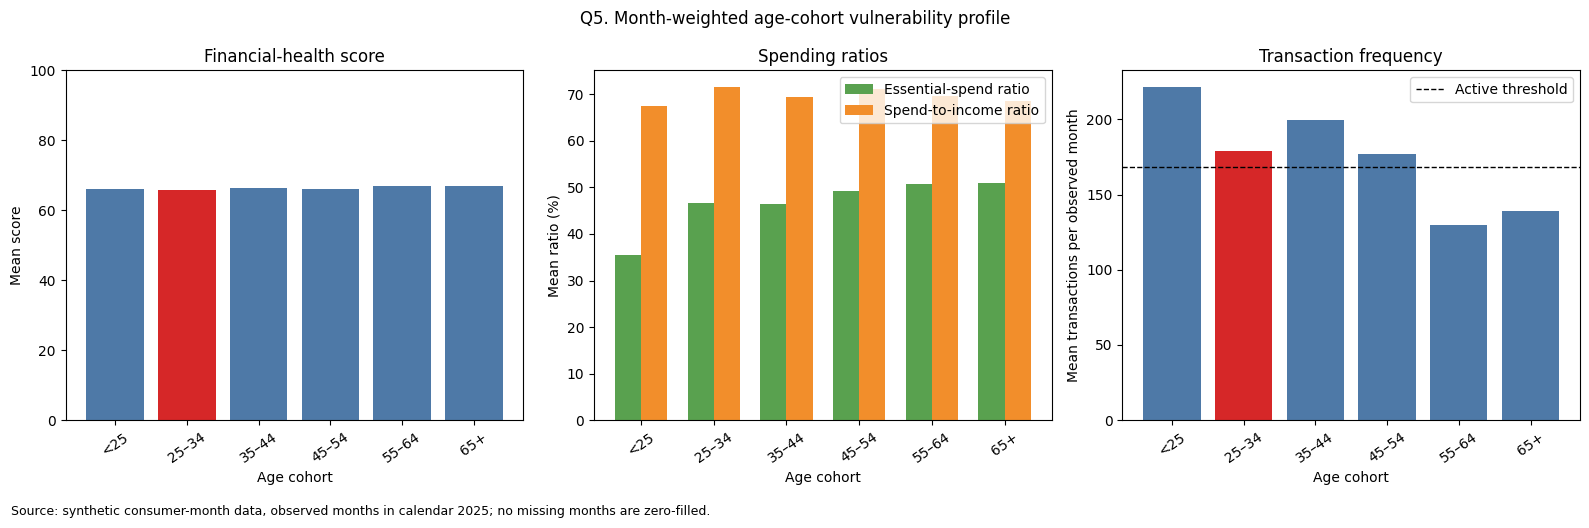

**Calculated interpretation.** Among cohorts meeting the **168.52** transaction active-frequency threshold, **25–34** has the lowest month-weighted health score at **65.79**, based on **2,124 consumer-months** and **177 customers**. Its mean essential-spend ratio is **46.75%** versus **46.59%** across the other cohort means; its spend-to-income ratio is **71.58%** versus **69.27%**. With equal customer weight, the selected active/lowest-health cohort is **<25**; the identity **changes**. The ratios identify association, not a causal driver or a basis for any credit decision.

In [16]:
q5_plot = q5_month_weighted.set_index("age_cohort").reindex(age_bin_labels)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_colors = ["#d62728" if cohort == q5_lowest_month_cohort else "#4e79a7" for cohort in age_bin_labels]
axes[0].bar(age_bin_labels, q5_plot["average_financial_health_score"], color=bar_colors)
axes[0].set(title="Financial-health score", xlabel="Age cohort", ylabel="Mean score", ylim=(0, 100))
axes[1].bar(np.arange(len(age_bin_labels)) - 0.18, q5_plot["average_essential_spend_ratio"] * 100, width=0.36, label="Essential-spend ratio", color="#59a14f")
axes[1].bar(np.arange(len(age_bin_labels)) + 0.18, q5_plot["average_spend_to_income_ratio"] * 100, width=0.36, label="Spend-to-income ratio", color="#f28e2b")
axes[1].set_xticks(np.arange(len(age_bin_labels)), age_bin_labels)
axes[1].set(title="Spending ratios", xlabel="Age cohort", ylabel="Mean ratio (%)")
axes[1].legend()
axes[2].bar(age_bin_labels, q5_plot["average_monthly_transactions"], color=bar_colors)
axes[2].axhline(overall_monthly_frequency, color="black", linestyle="--", linewidth=1, label="Active threshold")
axes[2].set(title="Transaction frequency", xlabel="Age cohort", ylabel="Mean transactions per observed month")
axes[2].legend()
for axis in axes:
    axis.tick_params(axis="x", rotation=35)
fig.suptitle("Q5. Month-weighted age-cohort vulnerability profile")
fig.text(0.01, -0.03, "Source: synthetic consumer-month data, observed months in calendar 2025; no missing months are zero-filled.", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "q5_age_cohort_vulnerability.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)
q5_selected_row = q5_plot.loc[q5_lowest_month_cohort]
q5_other_rows = q5_plot.drop(index=q5_lowest_month_cohort)
display(Markdown(
    f"**Calculated interpretation.** Among cohorts meeting the **{overall_monthly_frequency:.2f}** transaction active-frequency threshold, **{q5_lowest_month_cohort}** has the lowest month-weighted health score at "
    f"**{q5_selected_row['average_financial_health_score']:.2f}**, based on **{int(q5_selected_row['consumer_months']):,} consumer-months** and **{int(q5_selected_row['distinct_customers']):,} customers**. "
    f"Its mean essential-spend ratio is **{q5_selected_row['average_essential_spend_ratio']:.2%}** versus **{q5_other_rows['average_essential_spend_ratio'].mean():.2%}** across the other cohort means; "
    f"its spend-to-income ratio is **{q5_selected_row['average_spend_to_income_ratio']:.2%}** versus **{q5_other_rows['average_spend_to_income_ratio'].mean():.2%}**. "
    f"With equal customer weight, the selected active/lowest-health cohort is **{q5_lowest_customer_cohort}**; the identity **{'changes' if q5_sensitivity_changed else 'does not change'}**. "
    "The ratios identify association, not a causal driver or a basis for any credit decision."
))


**Interpretation and source.** The calculated statement below Figure Q5 reports the active-frequency cutoff, selected cohort, health score, ratio comparators, cohort sizes, and whether equal-customer weighting changes the selection. Unequal observed histories can affect the primary month-weighted view; the sensitivity addresses that weighting issue without inventing missing months. Source: synthetic consumer-month data, observed months in calendar 2025.

## Synthesis

The following compact audit table collects the computed answer to each official question. It is generated from the same objects used in the figures rather than from hard-coded conclusions.

In [17]:
synthesis = pd.DataFrame(
    {
        "question": ["Q1", "Q2", "Q3", "Q4", "Q5"],
        "computed_answer": [
            f"Peak {peak_month['analysis_month']:%b}: {peak_month['total_spend_vnd']:,.0f} VND ({peak_month['annual_spend_share']:.2%}); primary gap driver: {q1_primary_driver}",
            f"Stressed minus healthy essential share: {q2_essential_gap_pp:+.2f} pp (monetary weighted)",
            ", ".join(f"{row.province_city} ({row.digital_gap_vs_overall_pp:.2f} pp gap)" for row in q3_selected.itertuples(index=False)),
            f"Count: {count_leader['spending_category']}; spend: {spend_leader['spending_category']}",
            f"Active/lowest health: {q5_lowest_month_cohort}; equal-customer result: {q5_lowest_customer_cohort}",
        ],
    }
)
display(synthesis)


,question,computed_answer
0,Q1,"Peak Dec: 488,032,709,000 VND (15.04%); primar..."
1,Q2,Stressed minus healthy essential share: -31.10...
2,Q3,"Hà Nội (0.31 pp gap), Đồng Nai (0.46 pp gap)"
3,Q4,Count: Xăng dầu và di chuyển; spend: Siêu thị ...
4,Q5,Active/lowest health: 25–34; equal-customer re...


## Limitations

1. The data are synthetic; identities, geography, income, credit limits, and balances are fabricated. Absolute financial magnitudes are not realistic customer financial records.
2. Customers have unequal observed histories. Primary monthly results describe observed consumer-months only; missing months are not assumed to be zero or inactive.
3. Health and spending comparisons are descriptive associations. They do not establish causality and must not be used to approve/deny credit, reduce limits, or block accounts.
4. Digital (`transaction_channel != 'POS'`, including QR) and online (`online_transaction_flag == 1`) are separate source definitions.
5. The Q1 time pattern is measured across one synthetic year; no holiday, promotion, macroeconomic, or seasonal cause is supported by these files alone.
6. Province findings describe the generated sample and do not establish current adoption, infrastructure access, or contactability.

In [18]:
elapsed_seconds = time.perf_counter() - run_started_at
peak_rss_mib = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024
free_disk_gib = shutil.disk_usage(ARTIFACT_ROOT).free / (1024 ** 3)
runtime_diagnostics = pd.DataFrame(
    {
        "measure": ["Elapsed notebook time", "Peak process RSS", "Free disk after run"],
        "value": [elapsed_seconds, peak_rss_mib, free_disk_gib],
        "unit": ["seconds", "MiB", "GiB"],
    }
)
display(runtime_diagnostics.round(2))
print(f"Saved five Task 1 figures to {FIGURE_DIR}")


,measure,value,unit
0,Elapsed notebook time,9.72,seconds
1,Peak process RSS,299.58,MiB
2,Free disk after run,3.45,GiB


Saved five Task 1 figures to /home/pearspringmind/Studying/BI-UEL/image/task1
